# Earth2Studio Forecast Tutorial

NVIDIA Earth2Studio workflows: temperature, precipitation, hurricane tracking, wind, and synoptic analysis.

**Setup:** Install the kernel with `uv run python -m ipykernel install --user --name earth2 --display-name "Earth2 (Python 3.12)"`

[Earth2Studio documentation](https://nvidia.github.io/earth2studio/)

In [1]:
import os
from datetime import datetime, timedelta

import torch
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

import earth2studio.run as run
from earth2studio.models.px import FCN, GraphCastOperational
from earth2studio.models.dx import PrecipitationAFNO, TCTrackerWuDuan
from earth2studio.data import GFS, WB2ERA5, NCAR_ERA5, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

/home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


In [2]:
CONFIG = {
    "forecast_date": "2026-01-08",
    "precip_date": "2026-01-01",
    "florence_date": "2018-09-13",
    "helene_date": "2024-09-26",
    "nsteps": 10,
    "florence_nsteps": 25,
    "wind_nsteps": 16,
    "output_root": "outputs",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

for subdir in ["t2m", "precip", "florence", "wind", "overlay", "z500", "animations"]:
    os.makedirs(f"{CONFIG['output_root']}/{subdir}", exist_ok=True)

print(f"Device: {CONFIG['device']}")

Device: cuda


In [3]:
# Load models once — reused across all sections
fcn_model = FCN.load_model(FCN.load_default_package())
precip_model = PrecipitationAFNO.load_model(PrecipitationAFNO.load_default_package())
graphcast_model = GraphCastOperational.load_model(GraphCastOperational.load_default_package())
tracker = TCTrackerWuDuan()

# Data sources
gfs_data = GFS()
era5_data = WB2ERA5(cache=True, verbose=True)
ncar_data = NCAR_ERA5()

print("Models and data sources loaded.")

Models and data sources loaded.


In [7]:
# --- Shared utility functions ---

def compute_wind_speed(ds, step):
    """Extract u10m, v10m and compute scalar wind speed at a given lead time step."""
    u = ds["u10m"].isel(time=0, lead_time=step).values
    v = ds["v10m"].isel(time=0, lead_time=step).values
    speed = np.sqrt(u**2 + v**2)
    return u, v, speed


def add_cities(ax, city_list, default_offset=(0.22, 0.22)):
    """Plot city markers and labels on a cartopy axes."""
    text_kw = dict(fontsize=8, zorder=11,
                   path_effects=[pe.withStroke(linewidth=2, foreground="white")],
                   transform=ccrs.PlateCarree())
    marker_kw = dict(marker="o", color="red", markersize=3, zorder=10,
                     transform=ccrs.PlateCarree())
    for item in city_list:
        if len(item) == 3:
            name, lat, lon = item
            dx, dy = default_offset
        else:
            name, lat, lon, dx, dy = item
        ax.plot(lon, lat, **marker_kw)
        ax.text(lon + dx, lat + dy, name, **text_kw)


def run_model_tracker(model, data, tracker, start_time, nsteps, device, is_era5=False):
    """Run TC tracker on either a prognostic model or ERA5 reanalysis data.

    Returns the track tensor on CPU.
    """
    tracker.reset_path_buffer()

    if is_era5:
        times = [start_time + timedelta(hours=6 * i) for i in range(nsteps + 1)]
        for step, time in enumerate(times):
            da = data(time, tracker.input_coords()["variable"])
            x, coords = prep_data_array(da, device=device)
            output, output_coords = tracker(x, coords)
        return output.cpu()

    model = model.to(device)
    x, coords = fetch_data(
        source=data,
        time=to_time_array([start_time]),
        variable=model.input_coords()["variable"],
        lead_time=model.input_coords()["lead_time"],
        device=device,
    )
    x, coords = map_coords(x, coords, model.input_coords())
    iterator = model.create_iterator(x, coords)

    with tqdm(total=nsteps + 1, desc="Running inference") as pbar:
        for step, (x, coords) in enumerate(iterator):
            x, coords = map_coords(x, coords, tracker.input_coords())
            output, output_coords = tracker(x, coords)
            output = output[:, 0]
            pbar.update(1)
            if step == nsteps:
                break
    return output.cpu()


def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two points."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

## 2m Temperature Forecast

In [8]:
io_t2m = ZarrBackend(
    f"{CONFIG['output_root']}/t2m/fcn_gfs_forecast.zarr",
    backend_kwargs={"overwrite": True},
)
io_t2m = run.deterministic(
    [CONFIG["forecast_date"]], CONFIG["nsteps"], fcn_model, gfs_data, io_t2m
)
ds_t2m = xr.open_zarr(f"{CONFIG['output_root']}/t2m/fcn_gfs_forecast.zarr")
print("T2M forecast complete.")

2026-04-06 17:30:06.709 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-06 17:30:06.709 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-04-06 17:30:09.373 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 337303134-947326
2026-04-06 17:30:09.376 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 458275515-977912
2026-04-06 17:30:09.378 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 409106778-875921
2026-04-06 17:30:09.380 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 329645190-898530
2026-04-06 17:30:09.382 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 459253427-968705
2026-04-06 17:30:09.383 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:02<00:00, 11.99it/s]


2026-04-06 17:30:11.315 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-04-06 17:30:11.686 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Running inference: 100%|██████████| 11/11 [00:23<00:00,  2.16s/it]

2026-04-06 17:30:35.467 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
T2M forecast complete.


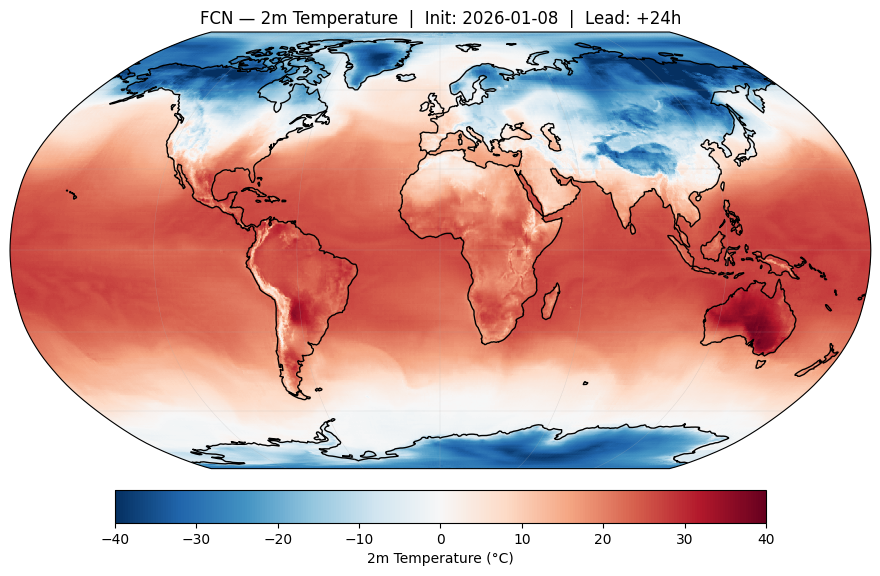

In [9]:
step = 4  # +24h
lead_hours = step * 6
t2m_c = ds_t2m["t2m"].isel(time=0, lead_time=step).values - 273.15

fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={"projection": ccrs.Robinson()})
im = ax.pcolormesh(
    ds_t2m["lon"], ds_t2m["lat"], t2m_c,
    transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-40, vmax=40, shading="auto",
)
cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.6)
cbar.set_label("2m Temperature (°C)")
ax.coastlines()
ax.gridlines(linewidth=0.3, alpha=0.4)
ax.set_title(f"FCN — 2m Temperature  |  Init: {CONFIG['forecast_date']}  |  Lead: +{lead_hours}h")
plt.savefig(f"{CONFIG['output_root']}/t2m/t2m_step{step:02d}.png", dpi=150, bbox_inches="tight")
plt.show()

## Total Precipitation

In [10]:
io_precip = ZarrBackend(
    f"{CONFIG['output_root']}/precip/fcn_precip_forecast.zarr",
    backend_kwargs={"overwrite": True},
)
io_precip = run.diagnostic(
    [CONFIG["precip_date"]], CONFIG["nsteps"],
    fcn_model, precip_model, gfs_data, io_precip,
)
ds_precip = xr.open_zarr(f"{CONFIG['output_root']}/precip/fcn_precip_forecast.zarr")
print("Precipitation forecast complete.")

2026-04-06 17:33:40.192 | INFO     | earth2studio.run:diagnostic:198 - Running diagnostic workflow!
2026-04-06 17:33:40.193 | INFO     | earth2studio.run:diagnostic:205 - Inference device: cuda


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-04-06 17:33:40.845 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 0-1005810
2026-04-06 17:33:40.848 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 337894898-870207
2026-04-06 17:33:40.850 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 422123816-947538
2026-04-06 17:33:40.852 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 406107233-993639
2026-04-06 17:33:40.853 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 428823385-1185530
2026-04-06 17:33:40.855 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib f

Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 22.01it/s]


2026-04-06 17:33:42.116 | SUCCESS  | earth2studio.run:diagnostic:228 - Fetched data from GFS
2026-04-06 17:33:42.191 | INFO     | earth2studio.run:diagnostic:260 - Inference starting!



Running inference: 100%|██████████| 11/11 [00:03<00:00,  3.28it/s]

2026-04-06 17:33:45.549 | SUCCESS  | earth2studio.run:diagnostic:276 - 
Inference complete
Precipitation forecast complete.


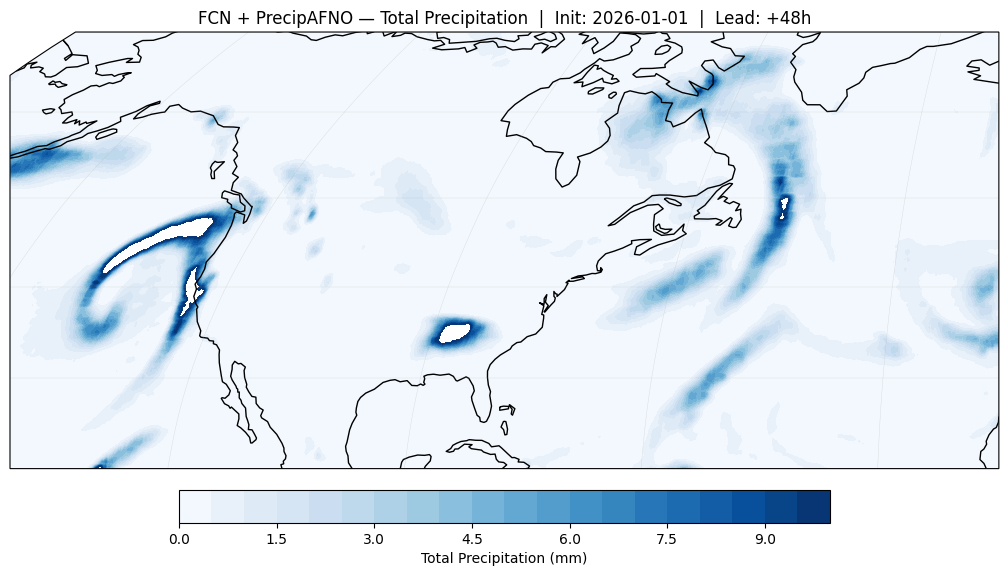

In [12]:
step = 8
lead_hours = step * 6
tp_mm = ds_precip["tp"].isel(time=0, lead_time=step).values * 1000  # m -> mm
extent = [220, 340, 20, 70]

fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={"projection": ccrs.Robinson()})
levels = np.linspace(0, 10, 21)
cf = ax.contourf(
    ds_precip["lon"], ds_precip["lat"], tp_mm, levels=levels,
    transform=ccrs.PlateCarree(), cmap="Blues", extend="neither",
)
cbar = plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.04, shrink=0.6)
cbar.set_label("Total Precipitation (mm)")
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(linewidth=0.3, alpha=0.4)
ax.set_title(f"FCN + PrecipAFNO — Total Precipitation  |  Init: {CONFIG['precip_date']}  |  Lead: +{lead_hours}h")
plt.savefig(f"{CONFIG['output_root']}/precip/precip_step{step:02d}.png", dpi=150, bbox_inches="tight")
plt.show()

## Hurricane Florence — Multi-Model Tracking

Compare ERA5, GraphCast, and FCN tropical cyclone tracks.

In [13]:
device = CONFIG["device"]
start_time = datetime.strptime(CONFIG["florence_date"], "%Y-%m-%d")
nsteps_fl = CONFIG["florence_nsteps"]
end_time = start_time + timedelta(hours=6 * nsteps_fl)
save_dir = f"{CONFIG['output_root']}/florence" 

In [14]:
# GraphCast tracker
graphcast_tracks = run_model_tracker(
    graphcast_model, era5_data, tracker, start_time, nsteps_fl, device
)
torch.save(graphcast_tracks, f"{save_dir}/graphcast_paths.pt")
print("GraphCast tracks saved.")

Fetching WB2 data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-06 17:42:10.350 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: z700 at 2018-09-12T18:00:00
2026-04-06 17:42:10.351 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: q600 at 2018-09-12T18:00:00
2026-04-06 17:42:10.353 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u600 at 2018-09-12T18:00:00
2026-04-06 17:42:10.354 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: q500 at 2018-09-12T18:00:00
2026-04-06 17:42:10.355 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t400 at 2018-09-12T18:00:00
2026-04-06 17:42:10.356 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u500 at 2018-09-12T18:00:00
2026-04-06 17:42:10.357 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: z925 at 2018-09-12T18:00:00

2026-04-06 17:42:10.937 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/87219.0.0.0 to local cache
2026-04-06 17:42:10.939 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/87219.0.0.0 to local cache
2026-04-06 17:42:10.941 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/mean_sea_level_pressure/87219.0.0 to local cache
2026-04-06 17:42:10.952 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/87219.0.0.0 to local cache
2026-04-06 17:42:10.953 | DEBUG    | earth2studio.data.utils:_make_loc

Fetching WB2 data:   0%|          | 0/82 [00:01<?, ?it/s]

2026-04-06 17:42:11.055 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/87219.0.0.0 to local cache


...

2026-04-06 17:42:32.960 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/87220.0.0.0 to local cache
2026-04-06 17:42:32.962 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/geopotential/87220.0.0.0 to local cache
2026-04-06 17:42:32.963 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/specific_humidity/87220.0.0.0 to local cache
2026-04-06 17:42:32.964 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/temperature/87220.0.0.0 to local cache
2026-04-06 17:42:32.966 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Co

Fetching WB2 data:   4%|▎         | 3/82 [00:00<00:21,  3.67it/s]

2026-04-06 17:42:33.553 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/vertical_velocity/87220.0.0.0 to local cache
2026-04-06 17:42:33.555 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/specific_humidity/87220.0.0.0 to local cache
2026-04-06 17:42:33.557 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/2m_temperature/87220.0.0 to local cache
2026-04-06 17:42:33.558 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/87220.0.0.0 to local cache
2026-04-06 17:42:33.560 | DEBUG    | earth2studio.data.utils:_make_local_details:73

Fetching WB2 data:  43%|████▎     | 35/82 [00:13<00:18,  2.49it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jovyan/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x763ce1413480> is already entered
Running inference:   0%|          | 0/26 [00:00<?, ?it/s]Task was destroyed but it is pending!
task: <Task pending name='Task-3719' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-3726' coro=<Kernel.shell_main() running at /home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jo

GraphCast tracks saved.


In [15]:
# ERA5 tracker (ground truth)
era5_tracks = run_model_tracker(
    None, era5_data, tracker, start_time, nsteps_fl, device, is_era5=True
)
torch.save(era5_tracks, f"{save_dir}/era5_paths.pt")
print("ERA5 tracks saved.")

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 69.89it/s]


2026-04-06 17:45:00.712 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T00:00:00
2026-04-06 17:45:00.713 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T00:00:00
2026-04-06 17:45:00.714 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T00:00:00
2026-04-06 17:45:00.716 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2018-09-13T00:00:00
2026-04-06 17:45:00.717 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T00:00:00


Fetching WB2 data:   0%|          | 0/5 [00:00<?, ?it/s]

2026-04-06 17:45:00.940 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T06:00:00
2026-04-06 17:45:00.941 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T06:00:00
2026-04-06 17:45:00.943 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T06:00:00
2026-04-06 17:45:00.944 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2018-09-13T06:00:00
2026-04-06 17:45:00.945 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T06:00:00


Fetching WB2 data:   0%|          | 0/5 [00:00<?, ?it/s]

...

2026-04-06 17:45:27.587 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2018-09-19T00:00:00
2026-04-06 17:45:27.588 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T00:00:00
2026-04-06 17:45:27.590 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T00:00:00
2026-04-06 17:45:27.591 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T00:00:00
2026-04-06 17:45:27.592 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T00:00:00
2026-04-06 17:45:27.676 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/10m_v_component_of_wind/87244.0.0 to local cache
2026-04-06 17:45:27.678 | DEBUG    | earth2studio.da

Fetching WB2 data:   0%|          | 0/5 [00:00<?, ?it/s]

2026-04-06 17:45:28.726 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T06:00:00
2026-04-06 17:45:28.727 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T06:00:00
2026-04-06 17:45:28.729 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T06:00:00
2026-04-06 17:45:28.730 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2018-09-19T06:00:00
2026-04-06 17:45:28.731 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T06:00:00
2026-04-06 17:45:28.814 | DEBUG    | earth2studio.data.utils:_make_local_details:739 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/v_component_of_wind/87245.0.0.0 to local cache
2026-04-06 17:45:28.817 | DEBUG    | earth2studio.data

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00,  7.10it/s]

ERA5 tracks saved.


In [17]:
# FCN tracker
fcn_model_florence = FCN.load_model(FCN.load_default_package())
fcn_tracks = run_model_tracker(
    fcn_model_florence, ncar_data, tracker, start_time, nsteps_fl, device
)
torch.save(fcn_tracks, f"{save_dir}/fcn_paths.pt")
print("FCN tracks saved.")

Fetching NCAR ERA5 data:   0%|          | 0/13 [00:00<?, ?it/s]

2026-04-06 17:54:59.243 | DEBUG    | earth2studio.data.ncar:fetch_array:398 - Fetching NCAR ERA5 variable: U in file s3://nsf-ncar-era5/e5.oper.an.pl/201809/e5.oper.an.pl.128_131_u.ll025uv.2018091300_2018091323.nc


Fetching NCAR ERA5 data:   0%|          | 0/13 [00:00<?, ?it/s]

2026-04-06 17:54:59.577 | DEBUG    | earth2studio.data.ncar:fetch_array:398 - Fetching NCAR ERA5 variable: 10V in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_166_10v.ll025sc.2018090100_2018093023.nc


Fetching NCAR ERA5 data:   0%|          | 0/13 [00:00<?, ?it/s]

...

2026-04-06 17:55:04.865 | DEBUG    | earth2studio.data.ncar:fetch_array:398 - Fetching NCAR ERA5 variable: MSL in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_151_msl.ll025sc.2018090100_2018093023.nc


Fetching NCAR ERA5 data:   0%|          | 0/13 [00:06<?, ?it/s]

2026-04-06 17:55:05.275 | DEBUG    | earth2studio.data.ncar:fetch_array:398 - Fetching NCAR ERA5 variable: 100U in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.228_246_100u.ll025sc.2018090100_2018093023.nc


ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jovyan/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x763ce1413480> is already entered
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-4519' coro=<_async_in_context.<locals>.run_in_context() running at /home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/ipykernel/utils.py:60> wait_for=<Task pending name='Task-4520' coro=<Kernel.shell_main() running at /home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
ERROR:a

FCN tracks saved.


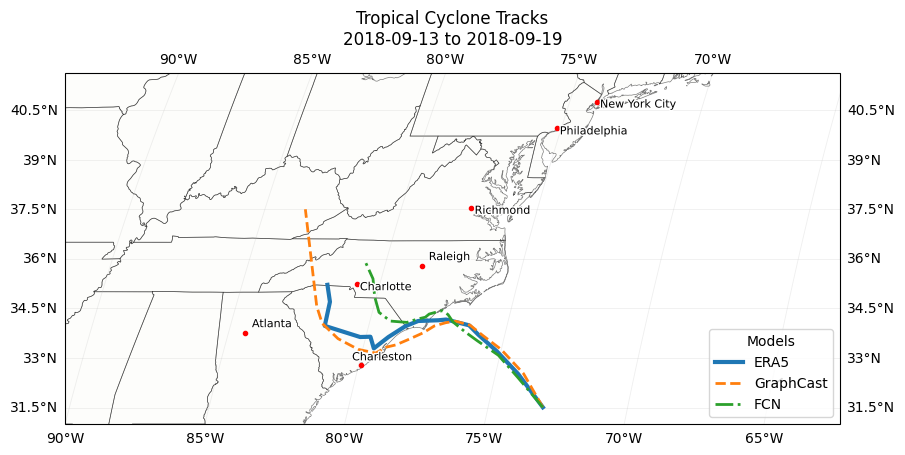

In [18]:
def plot_hurricane_tracks(models, start_time, end_time, extent, cities=None, figsize=(10, 8)):
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={"projection": ccrs.Robinson()})
    ax.add_feature(cfeature.LAND, alpha=0.1)
    ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.2)
    ax.set_extent(extent)

    for m in models:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()
        label_done = False
        for p in range(tracks.shape[1]):
            lats = tracks[0, p, :, 0]
            lons = tracks[0, p, :, 1]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.any() and len(lons[mask]) > 2:
                ax.plot(lons[mask], lats[mask], color=m["color"], linewidth=m.get("lw", 2),
                        linestyle=m.get("ls", "--"), label=m["name"] if not label_done else "",
                        transform=ccrs.PlateCarree(), zorder=6)
                label_done = True

    if cities:
        add_cities(ax, cities)
    ax.set_title(f"Tropical Cyclone Tracks\n{start_time:%Y-%m-%d} to {end_time:%Y-%m-%d}")
    ax.legend(loc="lower right", title="Models")
    return fig, ax


cities = [
    ("Charlotte", 35.2271, -80.8431, 0.18, -0.18),
    ("Raleigh", 35.7796, -78.6382, 0.18, 0.18),
    ("Charleston", 32.7765, -79.9311, -0.35, 0.15),
    ("Atlanta", 33.7490, -84.3880, 0.18, 0.18),
    ("Richmond", 37.5407, -77.4360, 0.18, -0.18),
    ("Philadelphia", 39.9526, -75.1652, 0.18, -0.18),
    ("New York City", 40.7685, -73.9822, 0.18, -0.18),
]

models_list = [
    {"name": "ERA5", "tracks": era5_tracks, "color": "#1f77b4", "lw": 3.0, "ls": "-"},
    {"name": "GraphCast", "tracks": graphcast_tracks, "color": "#ff7f0e", "lw": 2.0, "ls": "--"},
    {"name": "FCN", "tracks": fcn_tracks, "color": "#2ca02c", "lw": 2.0, "ls": "-."},
]

plot_hurricane_tracks(models_list, start_time, end_time, extent=(-90, -65, 31, 41), cities=cities)
plt.savefig(f"{save_dir}/florence_tracks.png", dpi=150, bbox_inches="tight")
plt.show()

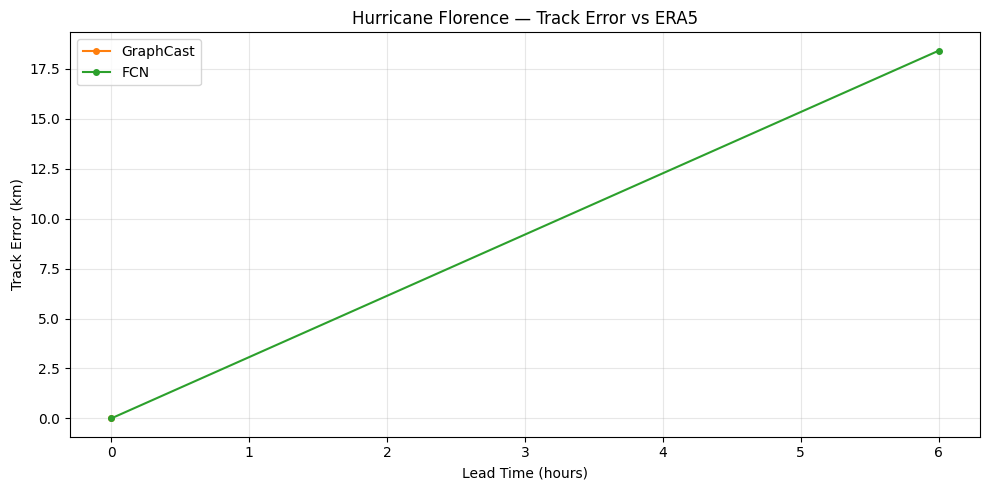

In [19]:
# Track error vs ERA5 (great-circle distance at each time step)
def extract_first_track(tracks_tensor):
    """Get (lats, lons) arrays for the first detected storm from a tracks tensor."""
    t = tracks_tensor.detach().cpu().numpy() if hasattr(tracks_tensor, "detach") else tracks_tensor
    lats = t[0, 0, :, 0]
    lons = t[0, 0, :, 1]
    return lats, lons

era5_lat, era5_lon = extract_first_track(era5_tracks)
hours = np.arange(len(era5_lat)) * 6

fig, ax = plt.subplots(figsize=(10, 5))
for m in models_list:
    if m["name"] == "ERA5":
        continue
    m_lat, m_lon = extract_first_track(m["tracks"])
    n = min(len(era5_lat), len(m_lat))
    errors = [haversine_km(era5_lat[i], era5_lon[i], m_lat[i], m_lon[i]) for i in range(n)
              if not (np.isnan(era5_lat[i]) or np.isnan(m_lat[i]))]
    valid_hours = [hours[i] for i in range(n)
                   if not (np.isnan(era5_lat[i]) or np.isnan(m_lat[i]))]
    ax.plot(valid_hours, errors, marker="o", markersize=4, label=m["name"], color=m["color"])

ax.set_xlabel("Lead Time (hours)")
ax.set_ylabel("Track Error (km)")
ax.set_title("Hurricane Florence — Track Error vs ERA5")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{save_dir}/track_error.png", dpi=150, bbox_inches="tight")
plt.show()

ERA5 serves as the observational reference. Track error measures the great-circle distance between each model's predicted storm center and the ERA5 position at each 6-hour step.

In [ ]:
# Quick re-plotting: load pre-saved tracks without re-running inference
# era5_tracks = torch.load(f"{save_dir}/era5_paths.pt", map_location="cpu")
# graphcast_tracks = torch.load(f"{save_dir}/graphcast_paths.pt", map_location="cpu")
# fcn_tracks = torch.load(f"{save_dir}/fcn_paths.pt", map_location="cpu")

## Wind Field — Hurricane Helene

In [20]:
io_wind = ZarrBackend(
    f"{CONFIG['output_root']}/wind/graphcast_wind_forecast.zarr",
    backend_kwargs={"overwrite": True},
)
io_wind = run.deterministic(
    [CONFIG["helene_date"]], CONFIG["wind_nsteps"], graphcast_model, gfs_data, io_wind
)
ds_wind = xr.open_zarr(f"{CONFIG['output_root']}/wind/graphcast_wind_forecast.zarr")
print("Wind forecast complete.")

2026-04-06 17:58:13.091 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-06 17:58:13.091 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching GFS data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-06 17:58:13.252 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 360049077-867458


Fetching GFS data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-06 17:58:13.342 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 235039728-710800
2026-04-06 17:58:13.380 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 197793871-586213
2026-04-06 17:58:13.412 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 335427337-859396
2026-04-06 17:58:13.437 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 181293175-754483


...

2026-04-06 17:58:25.048 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 155743299-911714
2026-04-06 17:58:25.093 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 185495690-1063234
2026-04-06 17:58:25.192 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 183121667-753797
2026-04-06 17:58:25.226 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 204809312-741003


Fetching GFS data: 100%|██████████| 82/82 [00:06<00:00, 13.41it/s]


2026-04-06 17:58:25.786 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-04-06 17:58:26.083 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Running inference: 100%|██████████| 17/17 [01:03<00:00,  3.76s/it]

2026-04-06 17:59:29.961 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
Wind forecast complete.


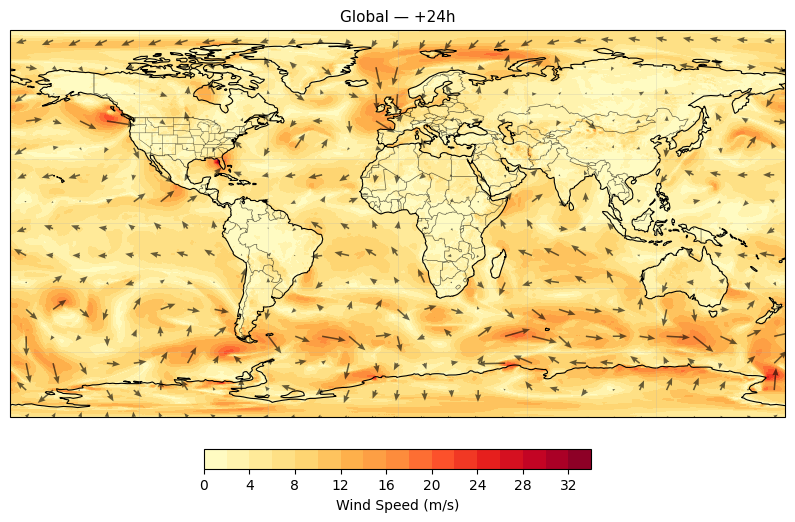

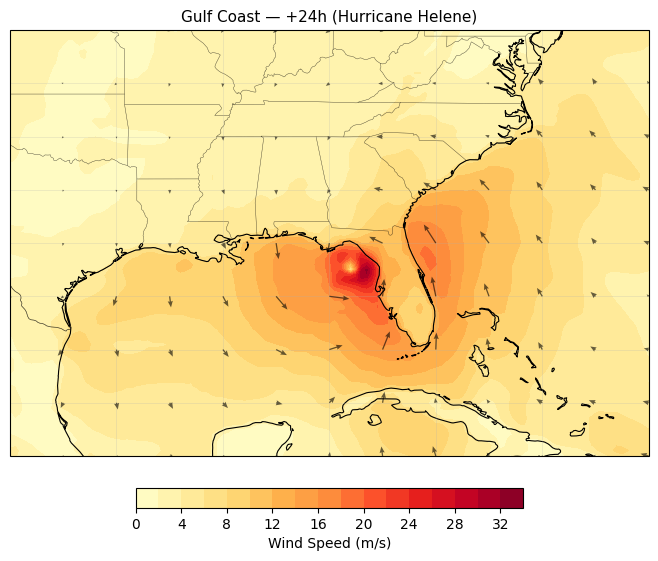

In [30]:
def plot_wind_field(ds, step, ax, extent=None, quiver_stride=20, title=None):
    """Plot wind speed contourf + quiver arrows on a given axes."""
    u, v, speed = compute_wind_speed(ds, step)
    lats, lons = ds["lat"].values, ds["lon"].values
    lead_hours = step * 6
    levels = np.arange(0, 35, 2)
    cf = ax.contourf(lons, lats, speed, levels=levels, cmap="YlOrRd",
                     transform=ccrs.PlateCarree(), extend="neither")
    lon_2d, lat_2d = np.meshgrid(lons, lats)
    s = quiver_stride
    ax.quiver(lon_2d[::s, ::s], lat_2d[::s, ::s], u[::s, ::s], v[::s, ::s],
              transform=ccrs.PlateCarree(), scale=500, width=0.002, headwidth=4,
              color="black", alpha=0.6, zorder=5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.6)
    ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.4)
    ax.gridlines(draw_labels=False, linewidth=0.4, alpha=0.4)
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    if title is None:
        title = f"GraphCast 10m Wind — +{lead_hours}h ({CONFIG['helene_date']})"
    ax.set_title(title, fontsize=11)
    return cf

# --- Global ---
fig, ax = plt.subplots(1, 1, figsize=(10, 7),
    subplot_kw={"projection": ccrs.PlateCarree()})
cf = plot_wind_field(ds_wind, step=4, ax=ax, quiver_stride=50, title="Global — +24h")
fig.colorbar(cf, ax=ax, orientation="horizontal", pad=0.06, shrink=0.5, label="Wind Speed (m/s)")
plt.savefig(f"{CONFIG['output_root']}/wind/wind_global.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Gulf Coast / Hurricane Helene ---
fig, ax = plt.subplots(1, 1, figsize=(10, 7),
    subplot_kw={"projection": ccrs.PlateCarree()})
cf = plot_wind_field(ds_wind, step=4, ax=ax, extent=[-100, -70, 20, 40],
                     quiver_stride=10, title="Gulf Coast — +24h (Hurricane Helene)")
fig.colorbar(cf, ax=ax, orientation="horizontal", pad=0.06, shrink=0.5, label="Wind Speed (m/s)")
plt.savefig(f"{CONFIG['output_root']}/wind/wind_regional.png", dpi=300, bbox_inches="tight")
plt.show()

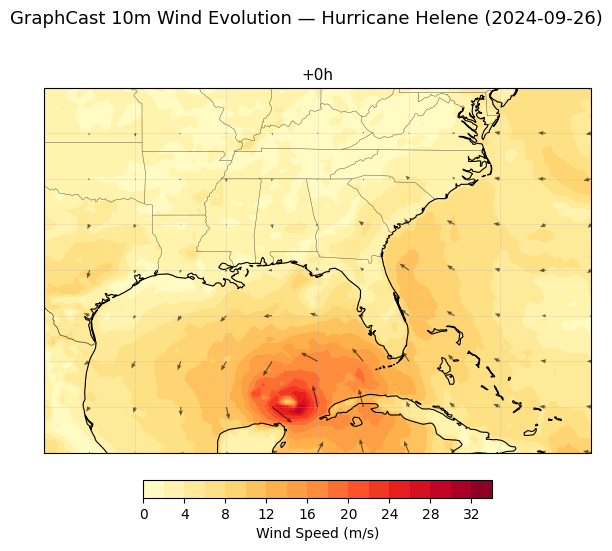

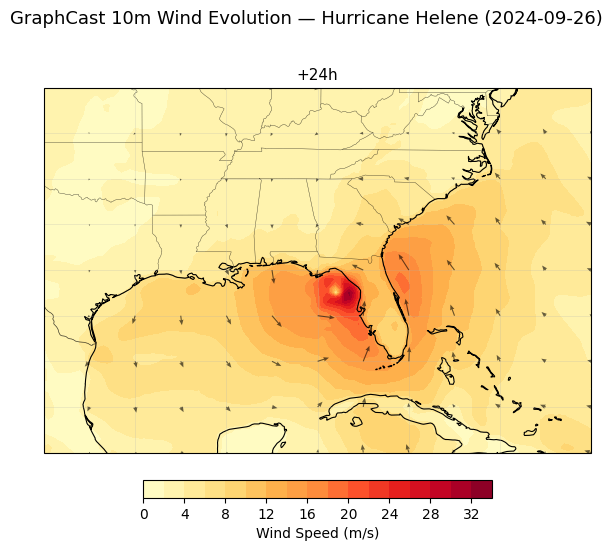

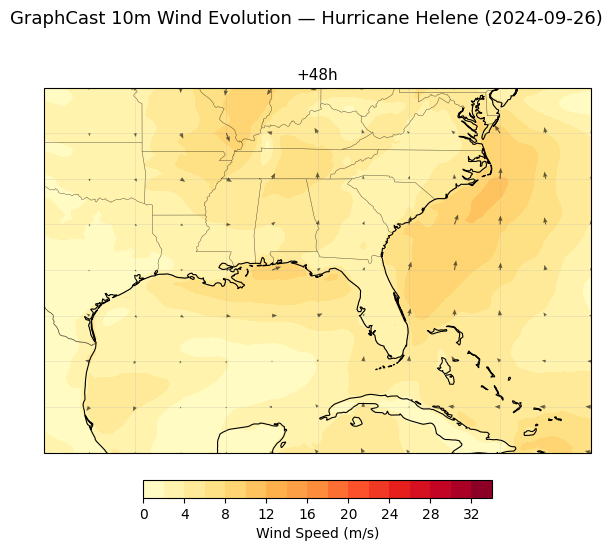

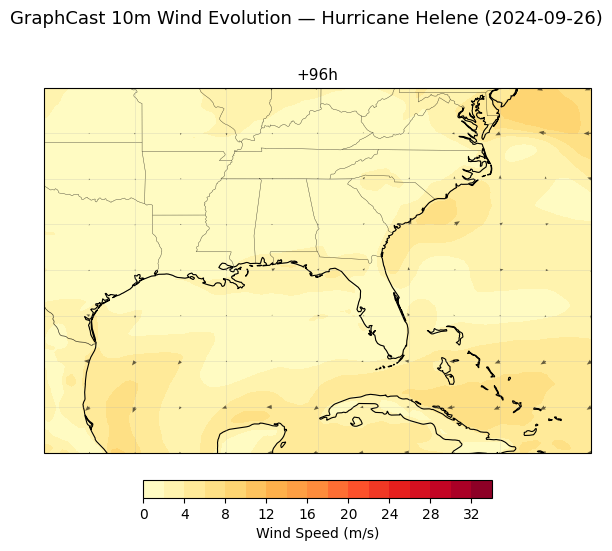

In [29]:
# Wind evolution: individual plots at key lead times
steps = [0, 4, 8, 16]

for step in steps:
    fig, ax = plt.subplots(1, 1, figsize=(9, 6),
        subplot_kw={"projection": ccrs.PlateCarree()})
    cf = plot_wind_field(ds_wind, step=step, ax=ax, extent=[-100, -70, 20, 40],
                         quiver_stride=10, title=f"+{step*6}h")
    fig.suptitle(f"GraphCast 10m Wind Evolution — Hurricane Helene ({CONFIG['helene_date']})",
                 fontsize=13, y=1.01)
    fig.colorbar(cf, ax=ax, orientation="horizontal", pad=0.06, shrink=0.5, label="Wind Speed (m/s)")
    plt.savefig(f"{CONFIG['output_root']}/wind/wind_evolution_{step*6}h.png", dpi=300, bbox_inches="tight")
    plt.show()

## Synoptic Analysis

MSL pressure + temperature overlay and 500 hPa geopotential height.

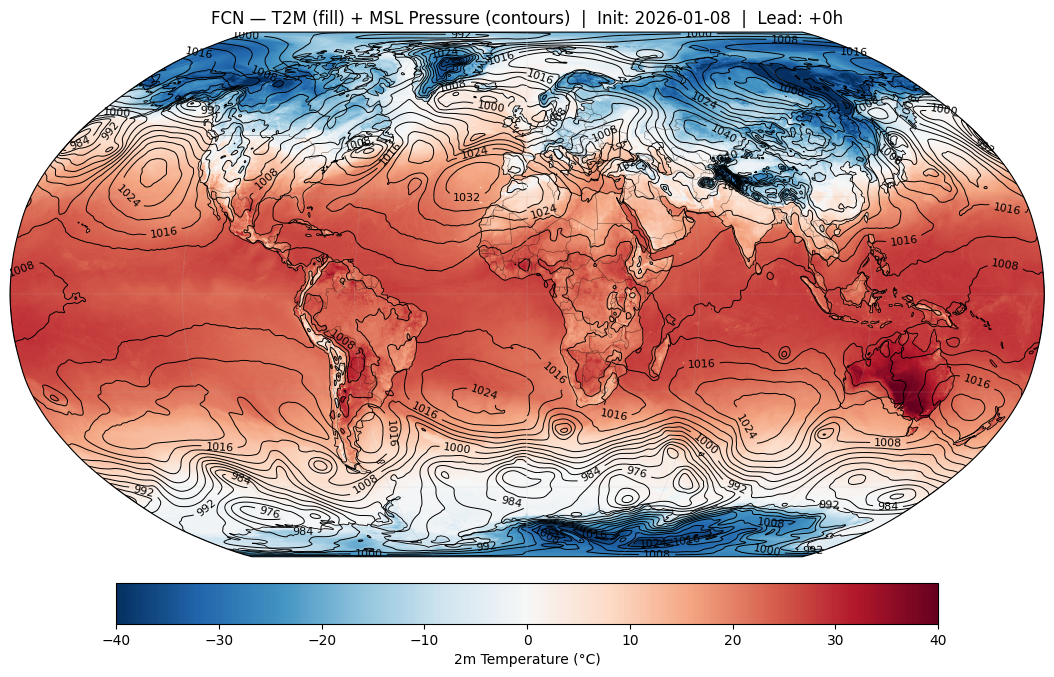

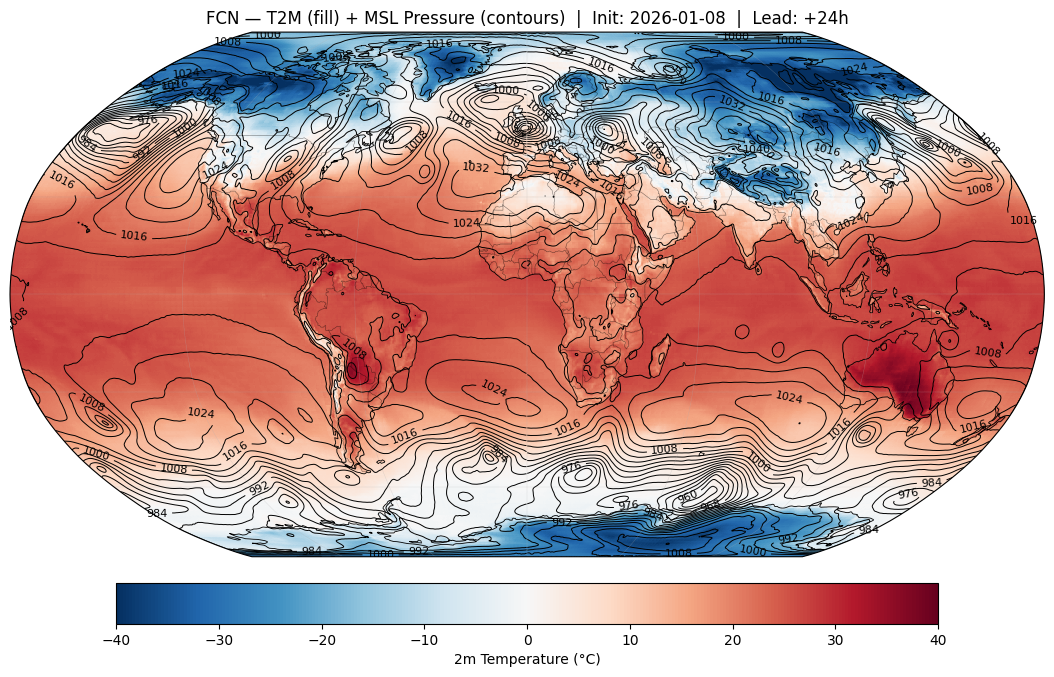

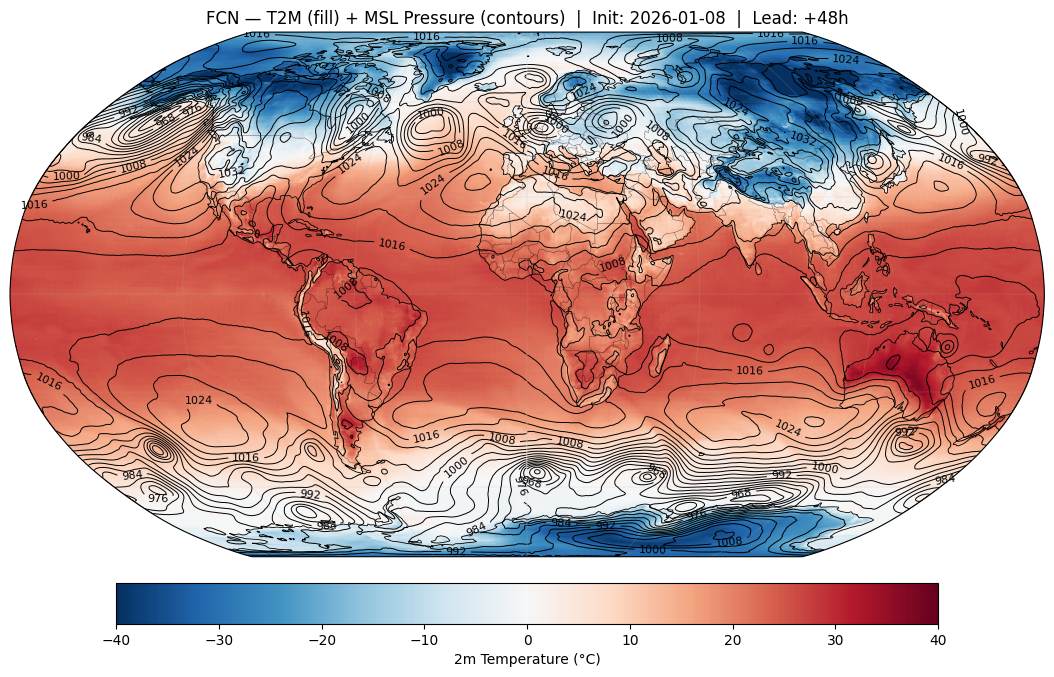

In [23]:
def plot_t2m_msl(ds, step, save_path=None):
    """Temperature fill + MSL pressure contours on Robinson projection."""
    lats, lons = ds["lat"].values, ds["lon"].values
    lead_hours = step * 6
    t2m_c = ds["t2m"].isel(time=0, lead_time=step).values - 273.15
    msl_hpa = gaussian_filter(ds["msl"].isel(time=0, lead_time=step).values / 100.0, sigma=1.5)

    fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={"projection": ccrs.Robinson()})
    cf = ax.pcolormesh(lons, lats, t2m_c, transform=ccrs.PlateCarree(),
                       cmap="RdBu_r", vmin=-40, vmax=40, shading="auto")
    cbar = plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.04, shrink=0.6)
    cbar.set_label("2m Temperature (°C)")

    p_min = int(np.floor(msl_hpa.min() / 4) * 4)
    p_max = int(np.ceil(msl_hpa.max() / 4) * 4)
    levels_msl = np.arange(p_min, p_max + 4, 4)
    cs = ax.contour(lons, lats, msl_hpa, levels=levels_msl, colors="black",
                    linewidths=0.7, transform=ccrs.PlateCarree())
    ax.clabel(cs, levels=levels_msl[::2], inline=True, fontsize=8, fmt="%d")

    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax.gridlines(linewidth=0.3, alpha=0.4)
    ax.set_title(f"FCN — T2M (fill) + MSL Pressure (contours)  |  Init: {CONFIG['forecast_date']}  |  Lead: +{lead_hours}h")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


for step in [0, 4, 8]:
    plot_t2m_msl(ds_t2m, step, save_path=f"{CONFIG['output_root']}/overlay/t2m_msl_step{step:02d}.png")

In [27]:
G = 9.80665

def get_z500_fields(ds, step):
    """Convert geopotential to height (m) and compute zonal anomaly."""
    z_raw = ds["z500"].isel(time=0, lead_time=step).values
    z_m = gaussian_filter(z_raw / G, sigma=1.0)
    anomaly = z_m - z_m.mean(axis=1, keepdims=True)
    return z_m, anomaly


def plot_z500(ds, step, save_path=None):
    lats, lons = ds["lat"].values, ds["lon"].values
    lead_hours = step * 6
    z_abs, z_anom = get_z500_fields(ds, step)

    fig, ax = plt.subplots(figsize=(10, 10),
        subplot_kw={"projection": ccrs.NorthPolarStereo(central_longitude=260)})
    ax.set_extent([-180, 180, 20, 90], crs=ccrs.PlateCarree())

    cf = ax.contourf(lons, lats, z_anom, levels=np.linspace(-150, 150, 31),
                     transform=ccrs.PlateCarree(), cmap="RdBu_r", extend="both")
    cbar = plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.04, shrink=0.7)
    cbar.set_label("Z500 Anomaly from Zonal Mean (m)")

    z_min = int(np.floor(z_abs.min() / 60) * 60)
    z_max = int(np.ceil(z_abs.max() / 60) * 60)
    cs = ax.contour(lons, lats, z_abs, levels=np.arange(z_min, z_max + 60, 60),
                    colors="black", linewidths=0.7, transform=ccrs.PlateCarree())
    ax.clabel(cs, inline=True, fontsize=7, fmt="%d")

    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax.gridlines(linewidth=0.4, alpha=0.4)
    ax.set_title(f"FCN — 500 hPa Height  |  Init: {CONFIG['forecast_date']}  |  Lead: +{lead_hours}h")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

Reusing T2M zarr store for z500 — no extra inference needed.


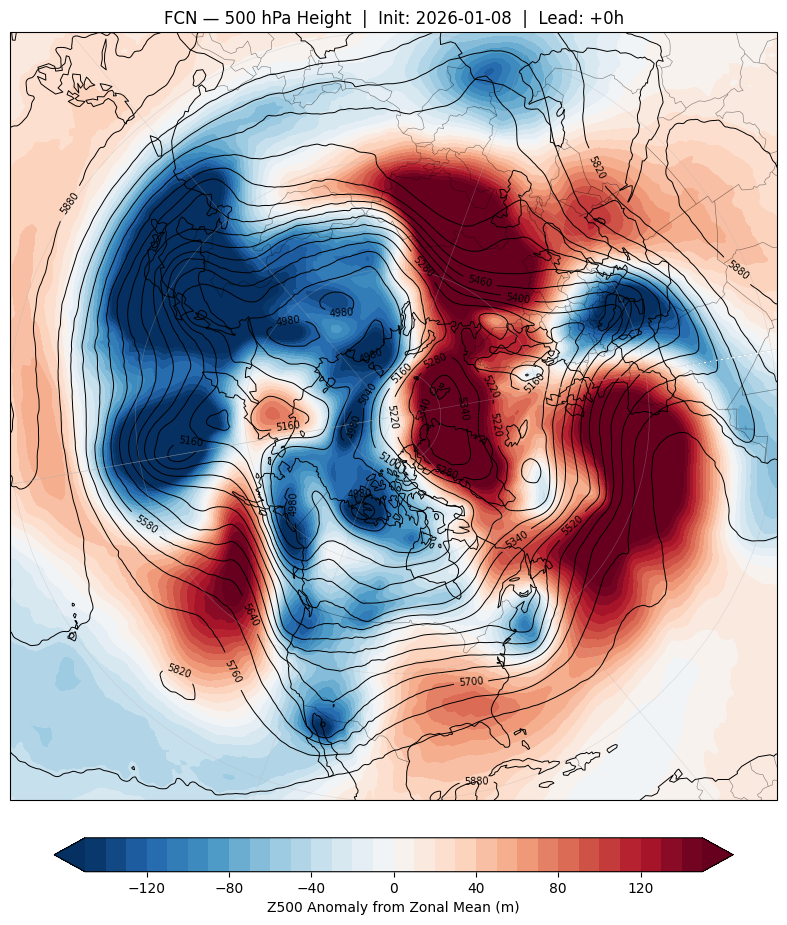

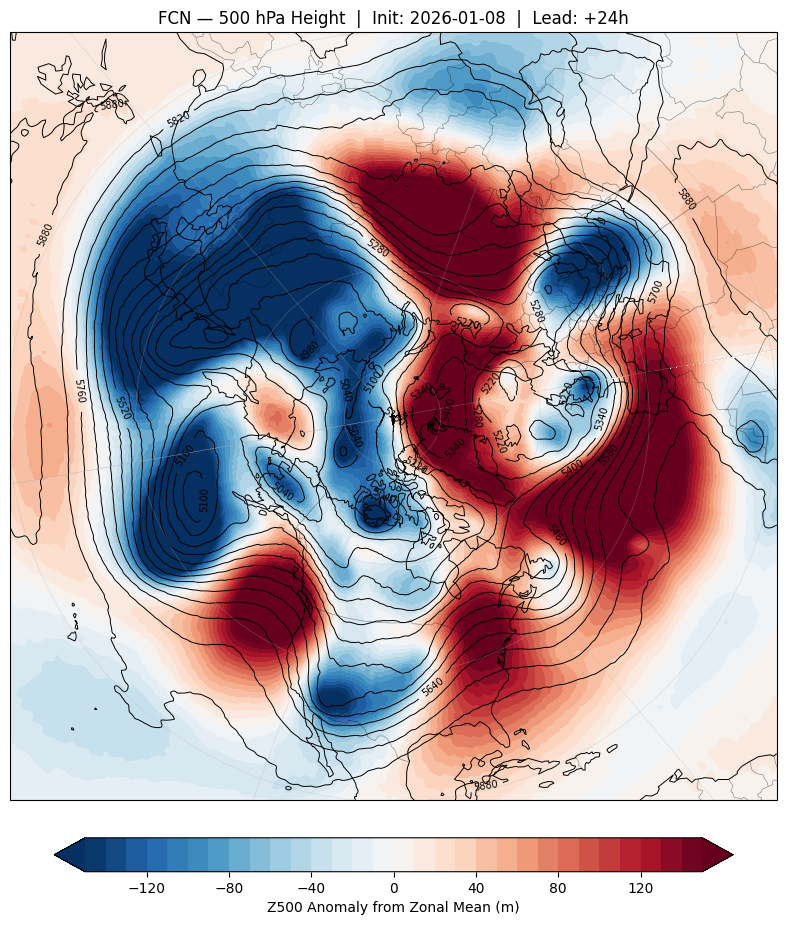

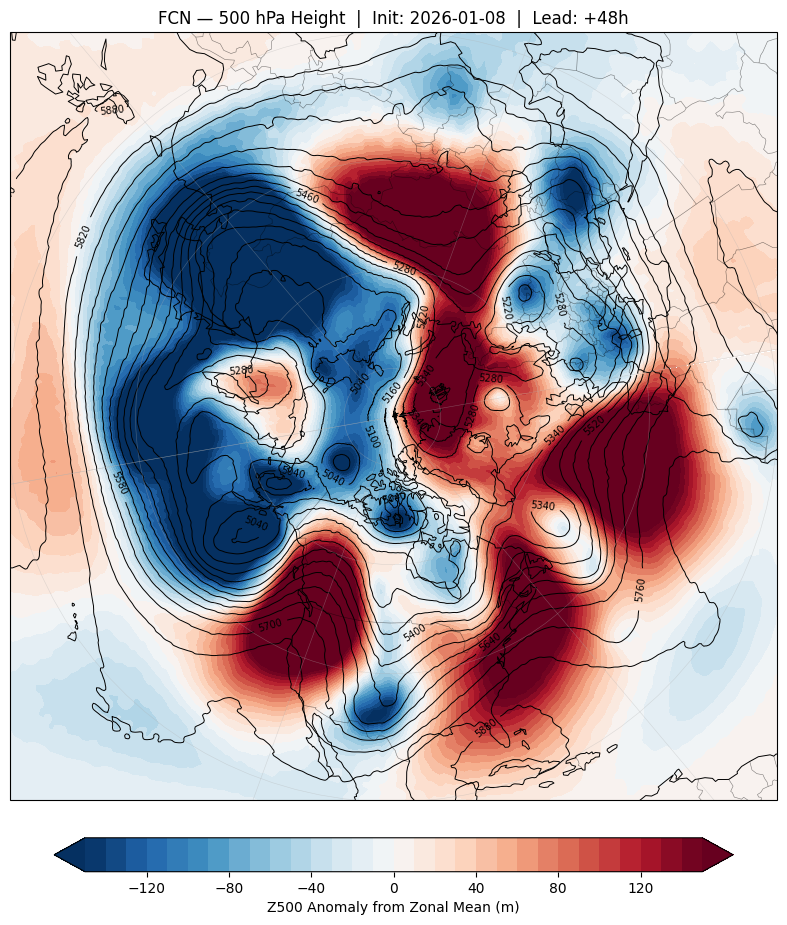

In [25]:
# Check if z500 is already in the T2M zarr store (FCN outputs all 26 variables)
if "z500" in ds_t2m.data_vars:
    ds_z500 = ds_t2m
    print("Reusing T2M zarr store for z500 — no extra inference needed.")
else:
    io_z500 = ZarrBackend(
        f"{CONFIG['output_root']}/z500/fcn_gfs_z500.zarr",
        backend_kwargs={"overwrite": True},
    )
    io_z500 = run.deterministic(
        [CONFIG["forecast_date"]], CONFIG["nsteps"], fcn_model, gfs_data, io_z500
    )
    ds_z500 = xr.open_zarr(f"{CONFIG['output_root']}/z500/fcn_gfs_z500.zarr")

for step in [0, 4, 8]:
    plot_z500(ds_z500, step, save_path=f"{CONFIG['output_root']}/z500/z500_step{step:02d}.png")

## Animations (Optional)

FileNotFoundError: [Errno 2] No such file or directory: 'ffmpeg'

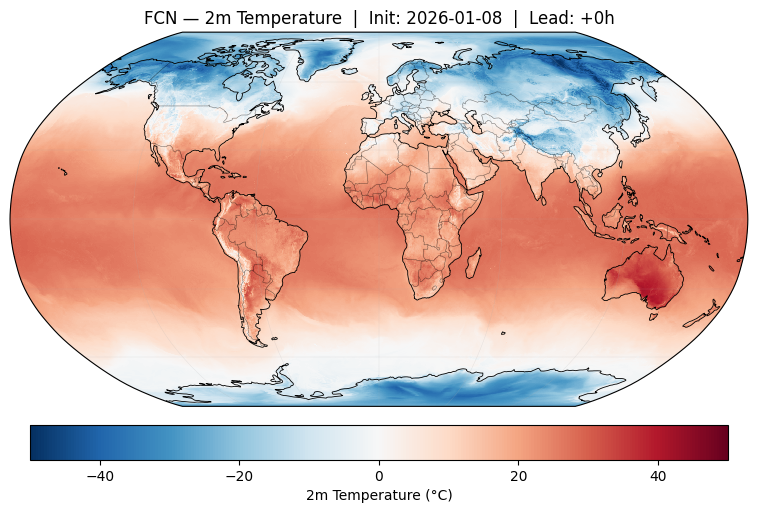

In [26]:
def make_t2m_animation(ds, save_path):
    lats, lons = ds["lat"].values, ds["lon"].values
    t2m_all = ds["t2m"].isel(time=0).values - 273.15

    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.Robinson()})
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax.gridlines(linewidth=0.3, alpha=0.3)

    mesh = ax.pcolormesh(lons, lats, t2m_all[0], transform=ccrs.PlateCarree(),
                         cmap="RdBu_r", vmin=-50, vmax=50, shading="auto")
    cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.04, shrink=0.75)
    cbar.set_label("2m Temperature (°C)")
    title = ax.set_title("")

    def update(step):
        mesh.set_array(t2m_all[step].ravel())
        title.set_text(f"FCN — 2m Temperature  |  Init: {CONFIG['forecast_date']}  |  Lead: +{step*6}h")
        return mesh, title

    anim = animation.FuncAnimation(fig, update, frames=t2m_all.shape[0], interval=350, blit=True)
    anim.save(save_path, writer=animation.FFMpegWriter(fps=3, bitrate=1800), dpi=120)
    plt.close(fig)
    print(f"Saved: {save_path}")

make_t2m_animation(ds_t2m, f"{CONFIG['output_root']}/animations/t2m_animation.mp4")

In [ ]:
def make_tp_animation(ds, save_path):
    lats, lons = ds["lat"].values, ds["lon"].values
    tp_all = ds["tp"].isel(time=0).values * 1000

    extent = [220, 310, 15, 75]
    levels = np.linspace(0, 8, 17)

    fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={"projection": ccrs.PlateCarree()})
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.4, alpha=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    gl.top_labels = gl.right_labels = False

    cf = ax.contourf(lons, lats, tp_all[0], levels=levels,
                     transform=ccrs.PlateCarree(), cmap="YlGnBu", extend="max")
    cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02, shrink=0.85)
    cbar.set_label("Total Precipitation (mm)")
    title = ax.set_title("")

    def update(step):
        for coll in ax.collections:
            coll.remove()
        ax.contourf(lons, lats, tp_all[step], levels=levels,
                    transform=ccrs.PlateCarree(), cmap="YlGnBu", extend="max")
        title.set_text(f"FCN + PrecipAFNO — Precipitation  |  Init: {CONFIG['precip_date']}  |  Lead: +{step*6}h")
        return []

    anim = animation.FuncAnimation(fig, update, frames=tp_all.shape[0], interval=400, blit=False)
    anim.save(save_path, writer=animation.FFMpegWriter(fps=2, bitrate=1800), dpi=120)
    plt.close(fig)
    print(f"Saved: {save_path}")

make_tp_animation(ds_precip, f"{CONFIG['output_root']}/animations/tp_animation.mp4")